# Build an Xopt object from completed scans

Construct a fully-fledged `Xopt` object — VOCS, generator, GP model — from one or more parameter scans, **without ever running an optimization**. Useful for two things:

1. **Surrogate analysis on existing data.** You ran a 1-D parameter scan (or a stack of them) and want to ask BO-style questions: "what does the GP think the surface looks like?", "what does EI / TuRBO say to try next?", "is there structure my eye missed?"
2. **Warm-starting a live BO run.** Pre-train the surrogate on past scan data, then swap the dummy evaluator for a real one and call `X.step()` to continue with live optimization. The pre-loaded data gives BO a head start instead of cold-starting from random samples.

Built on the same helpers as `xopt_run_inspection.ipynb` — model evolution, generator swap, GP diagnostics all work on the resulting `X` object once you've loaded the data.

**Assumed inputs:**
- One or more `ScanTag`s pointing at completed scans
- Names of the scan-parameter columns to treat as VOCS variables (alias-tolerant matching)
- Name of the s-file column carrying the objective scalar (run the analyzer first if it isn't there yet)
- Generator name from `PREDEFINED_GENERATORS`

In [1]:
import logging

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from xopt import Xopt
from xopt.vocs import VOCS

from geecs_data_utils import ScanPaths
from geecs_data_utils.scan_data import ScanData
from geecs_data_utils.config_roots import image_analysis_config
from geecs_scanner.optimization.generators.generator_factory import (
    build_generator_from_config,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logging.getLogger("image_analysis").setLevel(logging.ERROR)
logging.getLogger("geecs_data_utils").setLevel(logging.ERROR)
logging.getLogger("scan_analysis").setLevel(logging.ERROR)
image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

PosixPath('/Users/samuelbarber/Desktop/Code/Github_repos/GEECS-Plugins-Configs/image_analysis_configs')

## Configure the scans, variables, and objective

`SCANS` is a list of `(year, month, day, scan_number)` tuples. Adjust to whichever scans you want pooled into one Xopt object — they should share the variable columns you reference.

`VARIABLES` are the s-file columns to treat as VOCS variables. Use whatever bare names you'd type in VOCS form (`Device:variable.path`) — the matcher handles `Alias:` suffixes.

`OBJECTIVE_COLUMN` is the s-file column carrying the objective scalar. If it's not in your s-files yet, run the analyzer pre-step in the next cell.

In [11]:
EXPERIMENT = "Undulator"

# (year, month, day, scan_number) — extend freely
SCANS = [
    (2026, 5, 1, 19),
    # (2026, 5, 1, 20),
    # (2026, 5, 1, 21),
]

# VOCS variables in their canonical (colon-separated) form.
VARIABLES = [
    "U_HP_Daq:AnalogOutput.Channel 1",
    "U_ESP_JetXYZ:Position.Axis 1",
]

# s-file column with the analyzer's per-shot objective scalar.
OBJECTIVE_COLUMN = "U_BCaveMagSpec-interpSpec_objective"

# Sign multiplier — mirrors whatever your live evaluator does to the raw scalar.
# -1 matches `EBeamSourceOpt.compute_objective`'s `return -total`.
OBJECTIVE_SIGN: int = -1

# How to combine rows from the s-files into the Xopt data.
#   "per_shot" -> every shot is its own row (max info; GP fits real noise)
#   "per_bin"  -> average per Bin # within each scan (mirrors what live BO saw)
AGGREGATE: str = "per_shot"

# Generator name from PREDEFINED_GENERATORS. Same options as the other notebooks.
GENERATOR_NAME = "bayes_default"


# Optional row filter — return False to drop a row from the s-file load.
# Default keeps everything that has a finite objective.
def row_filter(row) -> bool:
    """Filter."""
    return pd.notna(row.get(OBJECTIVE_COLUMN))

## (Optional) populate the s-files with a per-shot objective

If `OBJECTIVE_COLUMN` doesn't already exist in your s-files, run the analyzer once across every scan in `SCANS`. Same machinery as the analyzer-execution cell in `xopt_run_inspection.ipynb`.

`live_analysis=False` tells the analyzer to auto-load the s-file and persist its scalar updates back to it. Skip this cell if your s-files already have the objective column.

In [3]:
# --- Uncomment + edit, then run once per fresh scan set ---

# from scan_analysis.analyzers.common.array1d_scan_analysis import Array1DScanAnalyzer
# from image_analysis.offline_analyzers.Undulator.BCaveMagSpecStitcherOpt import BCaveMagOpt
#
# analyzer = Array1DScanAnalyzer(
#     device_name="U_BCaveMagSpec",
#     image_analyzer=BCaveMagOpt(line_config_name="U_BCaveMagSpec-interpSpec"),
#     file_tail=".txt",
#     analysis_mode="per_shot",
#     data_device_name="U_BCaveMagSpec-interpSpec",
# )
# analyzer.live_analysis = False
#
# for (year, month, day, scan_number) in SCANS:
#     tag = ScanPaths.get_scan_tag(year=year, month=month, day=day,
#                                   number=scan_number, experiment=EXPERIMENT)
#     print(f"running analyzer on Scan{scan_number:03d} ({year}-{month:02d}-{day:02d})")
#     analyzer.run_analysis(scan_tag=tag)

## Helpers

`match_vocs_to_sfile_column` is the same alias-tolerant matcher we built for `xopt_run_inspection`. It converts canonical VOCS names (with colons) to whatever GEECS save-elements wrote to the s-file (spaces and `Alias:` suffixes).

`stitch_sfiles` loads each scan's s-file in full, tags every row with provenance (`scan_number`, plus the existing `Shotnumber`), and concatenates everything into one master DataFrame. The full pooled frame stays available for any downstream filtering or sanity checks ("show me all rows from scan 19 where Bin # > 5").

In [4]:
def match_vocs_to_sfile_column(vocs_name: str, df_columns) -> str:
    """Resolve VOCS-style name to the s-file column (alias-tolerant)."""
    cols = list(df_columns)
    if vocs_name in cols:
        return vocs_name
    bare = vocs_name.replace(":", " ", 1)
    if bare in cols:
        return bare
    aliased = [c for c in cols if c.startswith(bare + " Alias:")]
    if len(aliased) == 1:
        return aliased[0]
    if len(aliased) > 1:
        raise KeyError(f"Multiple alias matches for {vocs_name!r}: {aliased}")
    starts = [c for c in cols if c.startswith(bare) or c.startswith(vocs_name)]
    if len(starts) == 1:
        return starts[0]
    if len(starts) > 1:
        raise KeyError(f"Ambiguous prefix for {vocs_name!r}: {starts}")
    raise KeyError(
        f"No s-file column matches VOCS variable {vocs_name!r}. "
        f"Tried exact, {bare!r}, and '{bare} Alias:*'. "
        f"First 30 columns: {cols[:30]}"
    )


def stitch_sfiles(scans, experiment) -> pd.DataFrame:
    """Pool the s-files of every scan into one DataFrame.

    Each row keeps its full s-file contents plus a `scan_number` column
    identifying its source. The natural identifier for any pooled row is
    (scan_number, Shotnumber) — both columns survive the stitch.
    """
    frames = []
    for year, month, day, number in scans:
        sd = ScanData.from_date(
            year=year,
            month=month,
            day=day,
            number=number,
            experiment=experiment,
            append_paths=False,
            source="sfile",
        )
        df = sd.data_frame.copy()
        df["scan_number"] = number
        frames.append(df)
        print(f"  scan {number:03d}: {len(df)} rows, {len(df.columns)} columns")

    pooled = pd.concat(frames, ignore_index=True, sort=False)
    print(
        f"\nStitched: {len(pooled)} rows total across {len(scans)} scan(s); "
        f"{len(pooled.columns)} pooled columns"
    )
    return pooled

## Step 1 — Stitch the s-files

Loads every scan's s-file in full and concatenates them into one master DataFrame, `df_stitched`. Provenance columns: every row carries `scan_number` (which file it came from) and the s-file's own `Shotnumber` (which shot within that scan). Together those are a unique identifier you can use to map any row back to its source.

The full stitched frame is what downstream cells consume — but you can also poke at it directly here for sanity checks before going further.

In [5]:
df_stitched = stitch_sfiles(SCANS, EXPERIMENT)

# Sanity peek
print("\nProvenance columns: scan_number,", end=" ")
print("Shotnumber" if "Shotnumber" in df_stitched.columns else "Shotnumber MISSING (!)")
print(f"\nFirst 5 columns: {list(df_stitched.columns[:5])}")
print(f"Last 5 columns:  {list(df_stitched.columns[-5:])}")

# (Uncomment to inspect):
# df_stitched.head()

  scan 019: 649 rows, 64 columns

Stitched: 649 rows total across 1 scan(s); 64 pooled columns

Provenance columns: scan_number, Shotnumber

First 5 columns: ['Elapsed Time', 'Bin #', 'scan', 'U_BCaveHallProbe Field', 'U_BCaveHallProbe Rawfield']
Last 5 columns:  ['U_BCaveMagSpec_y_fwhm', 'U_BCaveMagSpec_y_peak_location', 'U_BCaveMagSpec_y_rms', 'U_BCaveMagSpec-interpSpec_objective', 'scan_number']


## Step 2 — Extract the Xopt-ready subset

From the stitched master frame, pull just the columns Xopt needs: the VOCS variables (alias-resolved), the objective column, and `Bin #` if we'll be aggregating per-bin. Apply the sign flip and rename the objective to the canonical `'f'` key for VOCS.

Because alias mapping can drift between scans, we resolve VOCS column names per `scan_number` so each scan's rows pull from the right column even if the alias text differs.

In [6]:
# Resolve VOCS -> s-file column name per scan (alias mapping can vary)
xopt_rows = []
for scan_num, group in df_stitched.groupby("scan_number"):
    var_to_col = {v: match_vocs_to_sfile_column(v, group.columns) for v in VARIABLES}
    aliased = [v for v in VARIABLES if v != var_to_col[v]]
    if aliased:
        print(f"  scan {scan_num}: {len(aliased)} variable(s) aliased")

    for _, row in group.iterrows():
        if not row_filter(row):
            continue
        if OBJECTIVE_COLUMN not in group.columns:
            raise KeyError(
                f"scan {scan_num}: objective column {OBJECTIVE_COLUMN!r} not in s-file. "
                f"Did the analyzer pre-step run? Available *_objective columns: "
                f"{[c for c in group.columns if 'objective' in c.lower()]}"
            )
        rec = {vname: float(row[var_to_col[vname]]) for vname in var_to_col}
        rec[OBJECTIVE_COLUMN] = float(row[OBJECTIVE_COLUMN])
        if "Bin #" in group.columns and pd.notna(row.get("Bin #")):
            rec["Bin #"] = int(row["Bin #"])
        rec["scan_number"] = int(scan_num)
        if "Shotnumber" in group.columns and pd.notna(row.get("Shotnumber")):
            rec["Shotnumber"] = int(row["Shotnumber"])
        xopt_rows.append(rec)

raw = pd.DataFrame(xopt_rows)
print(f"\nFiltered: {len(raw)} of {len(df_stitched)} stitched rows")

# Aggregate
if AGGREGATE == "per_shot":
    pooled = raw.copy()
elif AGGREGATE == "per_bin":
    if "Bin #" not in raw.columns:
        raise RuntimeError("AGGREGATE='per_bin' needs a 'Bin #' column in the s-files.")
    grp_cols = ["scan_number", "Bin #"]
    agg_cols = list(VARIABLES) + [OBJECTIVE_COLUMN]
    pooled = raw.groupby(grp_cols, as_index=False)[agg_cols].mean()
else:
    raise ValueError(f"Unknown AGGREGATE: {AGGREGATE!r}")

# Apply sign flip + rename objective to the canonical VOCS key 'f'
OBJ = "f"
pooled = pooled.rename(columns={OBJECTIVE_COLUMN: OBJ})
pooled[OBJ] = OBJECTIVE_SIGN * pooled[OBJ]

print(f"After AGGREGATE='{AGGREGATE}': {len(pooled)} row(s)")
print(
    f"Objective {OBJ!r} stats: min={pooled[OBJ].min():.4g}, "
    f"max={pooled[OBJ].max():.4g}, "
    f"mean={pooled[OBJ].mean():.4g}, std={pooled[OBJ].std():.4g}"
)

# Infer VOCS bounds (min/max across pooled data)
vocs_dict = {
    "variables": {
        v: [float(pooled[v].min()), float(pooled[v].max())] for v in VARIABLES
    },
    "objectives": {OBJ: "MINIMIZE"},
}
print("\nInferred VOCS variables:")
for v, (lo, hi) in vocs_dict["variables"].items():
    print(f"  {v}  bounds=[{lo:.4g}, {hi:.4g}]")

vocs = VOCS(**vocs_dict)

  scan 19: 2 variable(s) aliased

Filtered: 649 of 649 stitched rows
After AGGREGATE='per_shot': 649 row(s)
Objective 'f' stats: min=-4.574, max=-0, mean=-1.238, std=1.148

Inferred VOCS variables:
  U_HP_Daq:AnalogOutput.Channel 1  bounds=[2.2, 3.5]
  U_ESP_JetXYZ:Position.Axis 1  bounds=[3.5, 6]


## Build the Xopt object

Dummy evaluator (`lambda d: d`) — fine because we never call `X.step()`. The data goes onto **both** `X.data` and `X.generator.data` (the former is the user-facing record; the latter is what `generate(1)` reads). The double-feed is the workaround for the version-dependent quirk where `Xopt.add_data` doesn't always propagate; calling `add_data` directly on the generator fixes it for `generate(1)`.

After `train_model()`, the surrogate is fit and ready for inspection.

In [7]:
X = Xopt(
    generator=build_generator_from_config({"name": GENERATOR_NAME}, vocs),
    vocs=vocs,
    evaluator={"function": lambda d: d},
)

# Drop helper columns Xopt doesn't need (scan_number, Bin #) before adding
xopt_data = pooled[list(VARIABLES) + [OBJ]].reset_index(drop=True)
X.add_data(xopt_data)
# Guard against xopt versions where Xopt.add_data doesn't propagate to
# generator.data. In 2.6.7+ propagation works, so this is a no-op there.
if X.generator.data is None or len(X.generator.data) == 0:
    X.generator.add_data(xopt_data)
X.generator.train_model()

print(
    f"Xopt built: {len(X.data)} rows in X.data, "
    f"{len(X.generator.data)} rows in X.generator.data"
)
print(f"Variables : {vocs.variable_names}")
print(f"Objectives: {vocs.objective_names}")

2026-05-13 18:46:58,469 - xopt.generator - INFO - Initialized generator expected_improvement


Xopt built: 649 rows in X.data, 1298 rows in X.generator.data
Variables : ['U_ESP_JetXYZ:Position.Axis 1', 'U_HP_Daq:AnalogOutput.Channel 1']
Objectives: ['f']


## Inspect the surrogate

The same surface / acquisition / next-candidate helpers from `xopt_run_inspection.ipynb`. Once promoted into `geecs_scanner.optimization.inspection`, this cell collapses to a single import.

In [8]:
def evaluate_model_on_grid(
    model, vocs, var_names, reference_point=None, n_grid=50, objective_name=None
):
    """Return (Xg, Yg, mean, sigma) over a 2D grid for one objective."""
    reference_point = dict(reference_point or {})
    objective_name = objective_name or vocs.objective_names[0]
    vx, vy = var_names
    x = np.linspace(*vocs.variables[vx], n_grid)
    y = np.linspace(*vocs.variables[vy], n_grid)
    Xg, Yg = np.meshgrid(x, y)
    input_names = vocs.variable_names
    rows = []
    for xi, yi in zip(Xg.ravel(), Yg.ravel()):
        pt = dict(reference_point)
        pt[vx] = xi
        pt[vy] = yi
        for name in input_names:
            if name not in pt:
                lo, hi = vocs.variables[name]
                pt[name] = 0.5 * (lo + hi)
        rows.append([pt[name] for name in input_names])
    X_tensor = torch.tensor(rows, dtype=torch.double)
    with torch.no_grad():
        post = model.posterior(X_tensor)
        mean = post.mean.cpu().numpy()
        var = post.variance.cpu().numpy()
    output_names = vocs.objective_names + vocs.constraint_names
    obj_idx = output_names.index(objective_name)
    Z = mean[:, obj_idx].reshape(n_grid, n_grid)
    Sigma = np.sqrt(np.clip(var[:, obj_idx], 0, None)).reshape(n_grid, n_grid)
    return Xg, Yg, Z, Sigma


def acquisition_surface(generator, vocs, var_names, reference_point=None, n_grid=50):
    """Find acquisition surface."""
    reference_point = dict(reference_point or {})
    vx, vy = var_names
    x = np.linspace(*vocs.variables[vx], n_grid)
    y = np.linspace(*vocs.variables[vy], n_grid)
    Xg, Yg = np.meshgrid(x, y)
    input_names = vocs.variable_names
    rows = []
    for xi, yi in zip(Xg.ravel(), Yg.ravel()):
        pt = dict(reference_point)
        pt[vx] = xi
        pt[vy] = yi
        for name in input_names:
            if name not in pt:
                lo, hi = vocs.variables[name]
                pt[name] = 0.5 * (lo + hi)
        rows.append([pt[name] for name in input_names])
    X_tensor = torch.tensor(rows, dtype=torch.double)
    try:
        acq_fn = generator.get_acquisition(generator.model)
    except AttributeError:
        acq_fn = generator._get_acquisition(generator.model)
    X_acq = X_tensor.unsqueeze(1)
    with torch.no_grad():
        A = acq_fn(X_acq).cpu().numpy().reshape(n_grid, n_grid)
    return Xg, Yg, A


def next_candidate_xy(generator, var_names):
    """Find next candidate."""
    vx, vy = var_names
    try:
        cands = generator.generate(1)
        if not cands:
            return None
        pt = cands[0]
        return float(pt[vx]), float(pt[vy])
    except Exception as exc:
        print(f"  next-candidate generation failed: {exc}")
        return None

## Render the surrogate

Posterior mean + σ + acquisition surface, with the ★ marking BO's proposed next point. Same layout as `xopt_run_inspection.ipynb`'s model evolution cells.

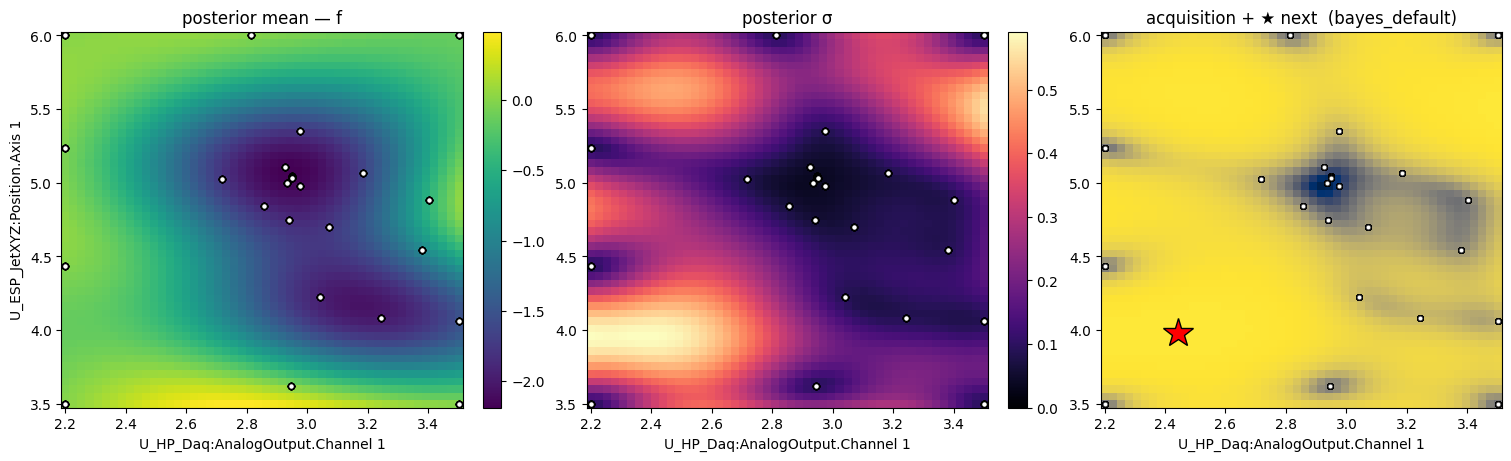

Next proposed candidate: (2.444, 3.978)


In [9]:
# Slice variables (the two we plot). For 2-D VOCS they're just the two variables.
# For higher-dim VOCS, edit to pick which two to slice over.
VAR_X, VAR_Y = VARIABLES[0], VARIABLES[1]
N_GRID = 50

# Reference point for any non-slice variables — observed best by default
obj_dir = vocs.objectives[OBJ]
best_row = (
    X.data.loc[X.data[OBJ].idxmax()]
    if str(obj_dir).upper() == "MAXIMIZE"
    else X.data.loc[X.data[OBJ].idxmin()]
)
REFERENCE_POINT = {
    name: float(best_row[name])
    for name in vocs.variable_names
    if name not in (VAR_X, VAR_Y)
}

Xg, Yg, Z, S = evaluate_model_on_grid(
    X.generator.model,
    vocs,
    (VAR_X, VAR_Y),
    reference_point=REFERENCE_POINT,
    n_grid=N_GRID,
    objective_name=OBJ,
)
_, _, A = acquisition_surface(
    X.generator,
    vocs,
    (VAR_X, VAR_Y),
    reference_point=REFERENCE_POINT,
    n_grid=N_GRID,
)
cand = next_candidate_xy(X.generator, (VAR_X, VAR_Y))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

pcm_m = axes[0].pcolormesh(Xg, Yg, Z, shading="auto", cmap="viridis")
axes[0].scatter(X.data[VAR_X], X.data[VAR_Y], c="white", edgecolor="k", s=18)
axes[0].set_title(f"posterior mean — {OBJ}")
axes[0].set_xlabel(VAR_X)
axes[0].set_ylabel(VAR_Y)
fig.colorbar(pcm_m, ax=axes[0])

pcm_s = axes[1].pcolormesh(Xg, Yg, S, vmin=0, shading="auto", cmap="magma")
axes[1].scatter(X.data[VAR_X], X.data[VAR_Y], c="white", edgecolor="k", s=18)
axes[1].set_title("posterior σ")
axes[1].set_xlabel(VAR_X)
fig.colorbar(pcm_s, ax=axes[1])

axes[2].pcolormesh(Xg, Yg, A, shading="auto", cmap="cividis")
axes[2].scatter(X.data[VAR_X], X.data[VAR_Y], c="white", edgecolor="k", s=14, alpha=0.6)
if cand is not None:
    axes[2].plot(
        cand[0], cand[1], marker="*", color="red", ms=22, markeredgecolor="black", lw=0
    )
axes[2].set_title(f"acquisition + ★ next  ({GENERATOR_NAME})")
axes[2].set_xlabel(VAR_X)

plt.show()
print(
    f"Next proposed candidate: ({cand[0]:.4g}, {cand[1]:.4g})"
    if cand
    else "No candidate proposed (check the warning above)."
)

In [10]:
X.data

,U_HP_Daq:AnalogOutput.Channel 1,U_ESP_JetXYZ:Position.Axis 1,f
0,2.940000,4.75001,-1.939013
1,2.940000,4.75001,-2.079571
2,2.940000,4.75001,-2.587288
3,2.940000,4.75001,-2.745972
4,2.940000,4.75001,-4.573929
...,...,...,...
644,2.925351,5.10429,-3.481337
645,2.925351,5.10429,-2.397767
646,2.925351,5.10429,-1.912547
647,2.925351,5.10429,-1.819400


## Notes & next steps

**Continuing as a live BO run.** The `X` object is fully primed — the surrogate is fit on whatever data you pooled. To switch from inspection to live optimization:

```python
from geecs_scanner.optimization.evaluators.bcavemagspec_opt import EBeamSourceOpt

# Replace the dummy evaluator with the real one (analyzer config etc.)
X.evaluator = {"function": EBeamSourceOpt(...)}

# Take a real BO step — uses the warm-started surrogate
X.step()
```

The pre-loaded scan data acts as a warm-start. BO's first proposal will already be informed by every shot in `SCANS`, instead of cold-starting from random samples.

**Promoting the helpers.** Once `geecs_scanner.optimization.inspection` exists, `evaluate_model_on_grid`, `acquisition_surface`, `next_candidate_xy`, and `match_vocs_to_sfile_column` all become one-line imports — cells 4 and 7 collapse dramatically. Same goes for the other two notebooks.

**Adding a generator-swap or model-evolution panel.** All the existing diagnostics from `xopt_run_inspection.ipynb` work on this `X` object too — they only need a fitted generator + a VOCS. Just copy the relevant cells over once you've decided which views are useful for your specific use case.

**What this notebook intentionally does NOT do.**
- Compute VOCS bounds with margin/padding. The default min/max is the most honest reflection of where data exists; if you want to query the GP outside it, edit `vocs.variables[name]` after construction.
- Validate that scan parameters were actually scanned. If a "variable" column has zero variance in the s-file, the GP will fit a degenerate kernel along that axis. The output of cell 5 prints the inferred bounds; flat ranges will be obvious.
- Auto-detect which VOCS variable went with which BO iteration. This notebook is for surrogate construction from arbitrary scans, not for replaying a structured BO run — for that, use `xopt_run_inspection.ipynb`.